In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [2]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [4]:
df.left.value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

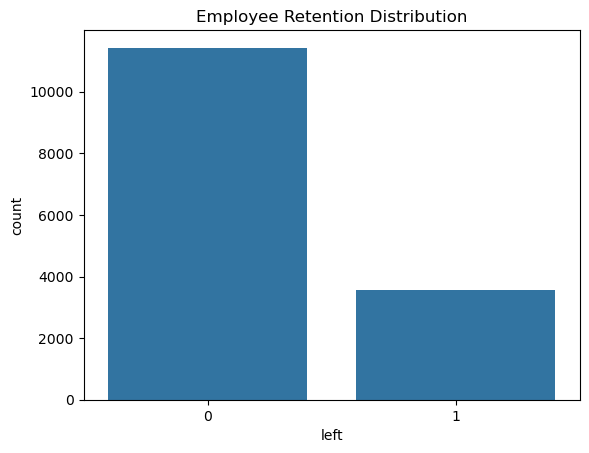

In [5]:
sns.countplot(x='left', data=df)
plt.title("Employee Retention Distribution")
plt.show()

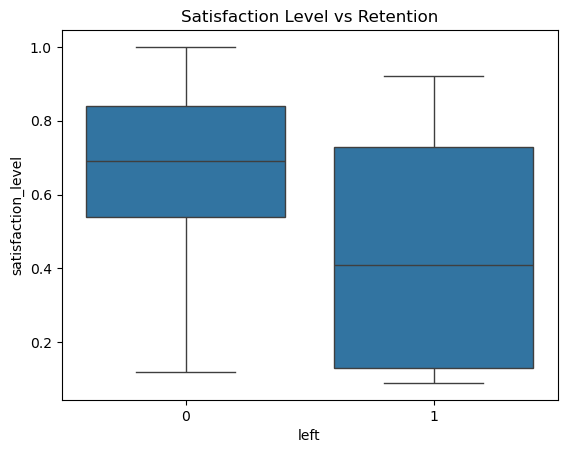

In [6]:
sns.boxplot(x='left', y='satisfaction_level', data=df)
plt.title("Satisfaction Level vs Retention")
plt.show()

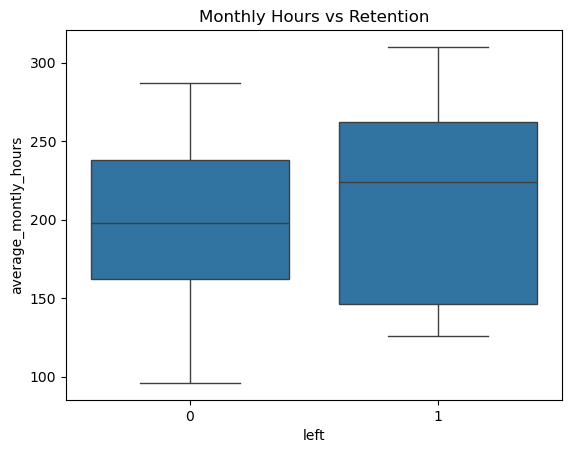

In [7]:
sns.boxplot(x='left', y='average_montly_hours', data=df)
plt.title("Monthly Hours vs Retention")
plt.show()

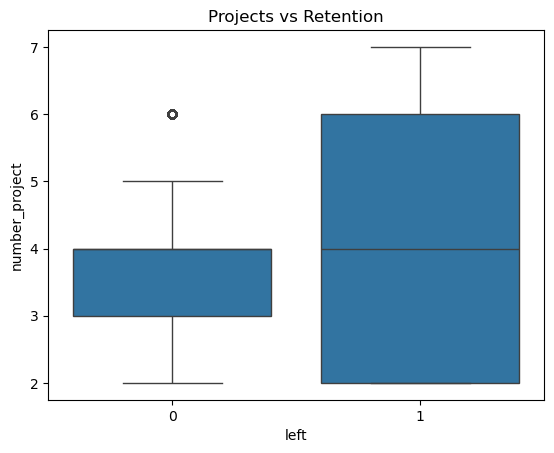

In [8]:
sns.boxplot(x='left', y='number_project', data=df)
plt.title("Projects vs Retention")
plt.show()

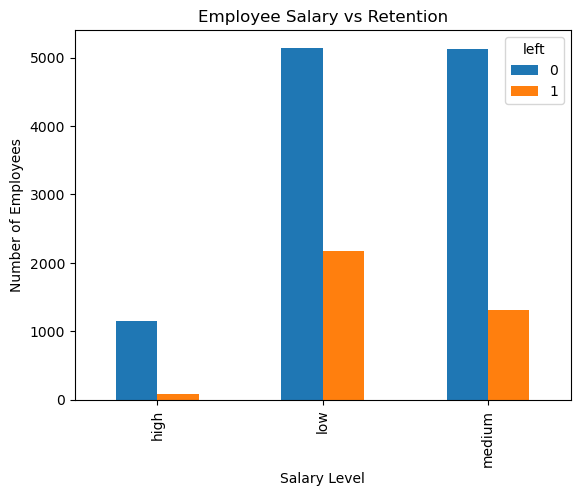

In [9]:
pd.crosstab(df.salary, df.left).plot(kind='bar')

plt.title("Employee Salary vs Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

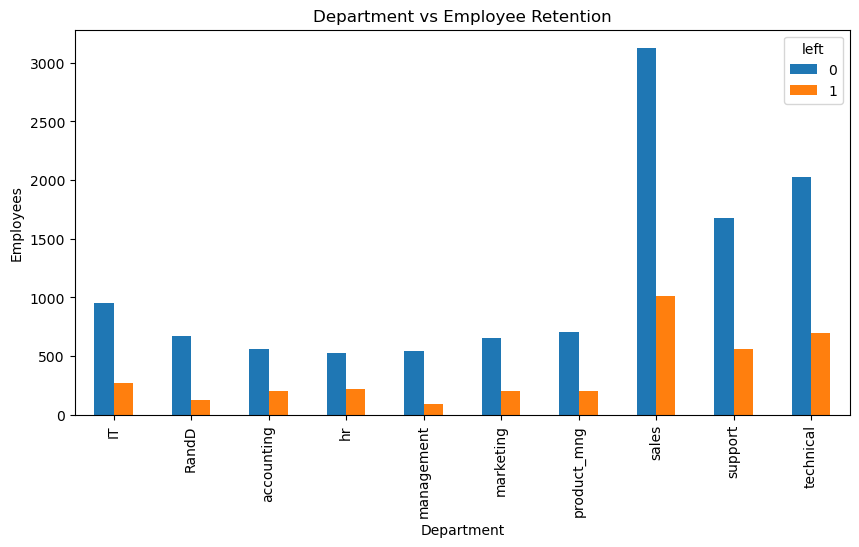

In [10]:
pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,5))

plt.title("Department vs Employee Retention")
plt.xlabel("Department")
plt.ylabel("Employees")
plt.show()

In [11]:
subdf = df[['satisfaction_level','average_montly_hours',
            'promotion_last_5years','salary','left']]

In [12]:
salary_dummies = pd.get_dummies(subdf.salary, prefix="salary")

df_with_dummies = pd.concat([subdf, salary_dummies], axis='columns')
df_with_dummies.drop('salary', axis='columns', inplace=True)

In [13]:
df_with_dummies.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,left,salary_high,salary_low,salary_medium
0,0.38,157,0,1,False,True,False
1,0.80,262,0,1,False,False,True
2,0.11,272,0,1,False,False,True
3,0.72,223,0,1,False,True,False
4,0.37,159,0,1,False,True,False


In [14]:
X = df_with_dummies.drop('left', axis='columns')
y = df_with_dummies.left

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [16]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.762
